## 04b - Enriched Customer Segmentation

### Objetivo
Construir una segmentación conductual enriquecida que permita distinguir claramente:

- clientes fieles,
- clientes de alto valor,
- compradores esporádicos,
- clientes en riesgo de abandono,
- y clientes sensibles a fricción en experiencia.

### Enfoque
Se parte de RFM como base interpretable y se enriquece con tres capas:

1. Valor y actividad:
   - recency
   - frequency
   - monetary
   - ticket promedio
   - total de ítems

2. Afinidad y comportamiento:
   - categoría favorita
   - diversidad de categorías
   - frecuencia de compra mensual
   - concentración del gasto

3. Riesgo y fricción:
   - mala experiencia
   - reseñas negativas
   - retrasos en entrega

## Resultado esperado
Generar un dataset `customer_360_features` reutilizable para:
- segmentación
- recomendación (personalización del agente)

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.loaders import load_all_datasets
from src.features.customer_features import (
    build_order_level_base,
    build_customer_rfm,
    add_rfm_scores,
)
from src.features.customer_360 import (
    build_item_level_customer_base,
    build_customer_360_features,
    assign_enriched_customer_segment,
)

In [3]:
TP_COLORS = {
    "blue_primary": "#2448A8",
    "blue_secondary": "#4C78E6",
    "blue_soft": "#6EC1E4",
    "yellow_accent": "#F2D22E",
    "gray_bg": "#F3F4F6",
    "gray_text": "#4B5563",
    "gray_muted": "#D1D5DB",
    "gray_dark": "#1F2937",
    "white": "#FFFFFF",
}

def fmt_int(x, pos=None):
    return f"{x:,.0f}"

def fmt_pct(x, pos=None):
    return f"{x:.0%}"

In [5]:
bundle = load_all_datasets()

customers = bundle.customers.copy()
orders = bundle.orders.copy()
order_items = bundle.order_items.copy()
order_reviews = bundle.order_reviews.copy()
products = bundle.products.copy()
translation = bundle.product_category_translation.copy()

In [6]:
## Construcción de dataset intermedio
order_base = build_order_level_base(
    orders=orders,
    order_items=order_items,
    customers=customers,
)

item_base = build_item_level_customer_base(
    orders=orders,
    order_items=order_items,
    order_reviews=order_reviews,
    customers=customers,
    products=products,
    translation=translation,
)

In [7]:
customer_rfm = build_customer_rfm(order_base)
customer_rfm = add_rfm_scores(customer_rfm)

customer_rfm.head()

,customer_unique_id,last_purchase_date,frequency,monetary,avg_order_value,total_items,n_cities,main_state,main_city,recency_days,R_score,F_score,M_score,RFM_score,rfm_numeric_score
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,129.90,129.90,1,1,SP,cajamar,112,4,1,4,414,9
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,18.90,18.90,1,1,SP,osasco,115,4,1,1,411,6
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,69.00,69.00,1,1,SC,sao jose,537,1,1,2,112,4
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,25.99,25.99,1,1,PA,belem,321,2,1,1,211,4
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,180.00,180.00,1,1,SP,sorocaba,288,2,1,5,215,8


### 1. Construcción de customer 360

In [8]:
customer_360 = build_customer_360_features(
    customer_rfm=customer_rfm,
    item_base=item_base,
)

customer_360 = assign_enriched_customer_segment(customer_360)

customer_360.head()

,customer_unique_id,last_purchase_date,frequency,monetary,avg_order_value,total_items,n_cities,main_state,main_city,recency_days,...,avg_delay_days_customer,purchase_history_summary,days_since_first_purchase,customer_lifetime_days,value_score,engagement_score,friction_score,inactivity_risk_score,customer_health_score,customer_segment_enriched
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,129.90,129.90,1,1,SP,cajamar,112,...,-5.0,Top categories: bed_bath_table,0,0,0.006242,0.39089,0.00,0.451192,0.197629,Friction-sensitive
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,18.90,18.90,1,1,SP,osasco,115,...,-5.0,Top categories: health_beauty,0,0,0.000873,0.39089,0.00,0.453927,0.195750,Friction-sensitive
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,69.00,69.00,1,1,SC,sao jose,537,...,-2.0,Top categories: stationery,0,0,0.003296,0.05339,0.25,0.838640,-0.009651,At risk
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,25.99,25.99,1,1,PA,belem,321,...,-12.0,Top categories: telephony,0,0,0.001216,0.16589,0.00,0.641725,0.083370,Occasional
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,180.00,180.00,1,1,SP,sorocaba,288,...,-8.0,Top categories: telephony,0,0,0.008665,0.16589,0.00,0.611641,0.085978,Occasional


In [9]:
customer_360.columns.tolist()

['customer_unique_id',
 'last_purchase_date',
 'frequency',
 'monetary',
 'avg_order_value',
 'total_items',
 'n_cities',
 'main_state',
 'main_city',
 'recency_days',
 'R_score',
 'F_score',
 'M_score',
 'RFM_score',
 'rfm_numeric_score',
 'first_purchase_date',
 'last_purchase_date_behavior',
 'total_orders',
 'total_items_behavior',
 'total_revenue',
 'avg_order_value_behavior',
 'category_diversity',
 'main_state_behavior',
 'main_city_behavior',
 'favorite_category',
 'purchase_span_days',
 'months_active',
 'purchase_frequency_per_month',
 'favorite_category_revenue',
 'top_category_share',
 'avg_review_score_customer',
 'bad_review_rate_customer',
 'neutral_or_worse_review_rate_customer',
 'late_delivery_rate_customer',
 'avg_delay_days_customer',
 'purchase_history_summary',
 'days_since_first_purchase',
 'customer_lifetime_days',
 'value_score',
 'engagement_score',
 'friction_score',
 'inactivity_risk_score',
 'customer_health_score',
 'customer_segment_enriched']

## 2. Resumen de segmentos

In [10]:
segment_summary = (
    customer_360.groupby("customer_segment_enriched", as_index=False)
    .agg(
        n_customers=("customer_unique_id", "nunique"),
        avg_recency_days=("recency_days", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_value_score=("value_score", "mean"),
        avg_engagement_score=("engagement_score", "mean"),
        avg_friction_score=("friction_score", "mean"),
        avg_inactivity_risk_score=("inactivity_risk_score", "mean"),
    )
    .sort_values("n_customers", ascending=False)
    .reset_index(drop=True)
)

segment_summary["share_pct"] = segment_summary["n_customers"] / segment_summary["n_customers"].sum()
segment_summary

,customer_segment_enriched,n_customers,avg_recency_days,avg_frequency,avg_monetary,avg_order_value,avg_value_score,avg_engagement_score,avg_friction_score,avg_inactivity_risk_score,share_pct
0,Friction-sensitive,37268,92.804900,1.012209,141.483705,140.050963,0.007669,0.444434,0.124941,0.433388,0.399194
1,Occasional,31799,255.635838,1.033334,138.039469,133.921388,0.007967,0.231648,0.154848,0.581303,0.340614
2,At risk,14373,450.695749,1.000000,58.576614,58.576614,0.002814,0.076382,0.098817,0.759961,0.153956
3,At risk high-value,9080,451.108260,1.070044,273.783383,265.559338,0.016138,0.082098,0.118728,0.758586,0.097260
4,Loyal high-value,837,62.249701,2.155317,275.982975,126.896525,0.039012,0.510810,0.094044,0.376955,0.008965
5,Loyal,1,135.000000,3.000000,293.800000,97.933333,0.055664,0.609534,0.000000,0.422160,0.000011


### 2.1 Visualización de la distribución de segmentos

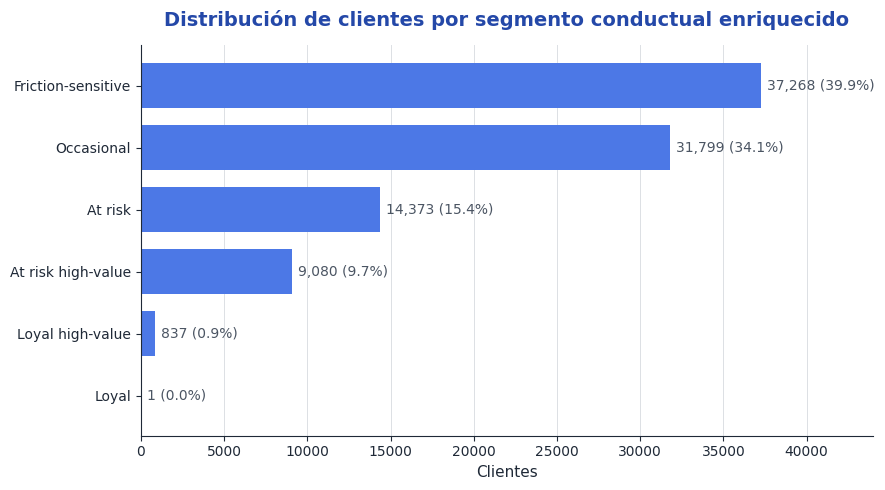

In [11]:
plot_df = segment_summary.sort_values("n_customers", ascending=True).copy()

fig, ax = plt.subplots(figsize=(9, 5), facecolor=TP_COLORS["white"])
ax.set_facecolor(TP_COLORS["white"])

ax.barh(
    plot_df["customer_segment_enriched"],
    plot_df["n_customers"],
    color=TP_COLORS["blue_secondary"],
    edgecolor="none",
    height=0.72
)

ax.set_title(
    "Distribución de clientes por segmento conductual enriquecido",
    fontsize=14,
    fontweight="bold",
    color=TP_COLORS["blue_primary"],
    pad=14
)
ax.set_xlabel("Clientes", color=TP_COLORS["gray_dark"], fontsize=11)
ax.set_ylabel("")

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
ax.spines["left"].set_color(TP_COLORS["gray_dark"])
ax.spines["bottom"].set_color(TP_COLORS["gray_dark"])

ax.tick_params(axis="x", colors=TP_COLORS["gray_dark"], labelsize=10)
ax.tick_params(axis="y", colors=TP_COLORS["gray_dark"], labelsize=10)

ax.xaxis.grid(True, linestyle="-", linewidth=0.7, color=TP_COLORS["gray_muted"], alpha=0.75)
ax.set_axisbelow(True)

max_val = plot_df["n_customers"].max()

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(
        row["n_customers"] + max_val * 0.01,
        i,
        f'{row["n_customers"]:,.0f} ({row["share_pct"]:.1%})',
        va="center",
        ha="left",
        color=TP_COLORS["gray_text"],
        fontsize=10
    )

ax.set_xlim(0, max_val * 1.18)

plt.tight_layout()
plt.show()

## 2.1 Perfil comparativo por segmento
Quremos entender el “ADN” de cada grupo.

In [12]:
segment_profile = segment_summary[[
    "customer_segment_enriched",
    "n_customers",
    "share_pct",
    "avg_recency_days",
    "avg_frequency",
    "avg_monetary",
    "avg_order_value",
    "avg_value_score",
    "avg_engagement_score",
    "avg_friction_score",
    "avg_inactivity_risk_score",
]].copy()

segment_profile

,customer_segment_enriched,n_customers,share_pct,avg_recency_days,avg_frequency,avg_monetary,avg_order_value,avg_value_score,avg_engagement_score,avg_friction_score,avg_inactivity_risk_score
0,Friction-sensitive,37268,0.399194,92.804900,1.012209,141.483705,140.050963,0.007669,0.444434,0.124941,0.433388
1,Occasional,31799,0.340614,255.635838,1.033334,138.039469,133.921388,0.007967,0.231648,0.154848,0.581303
2,At risk,14373,0.153956,450.695749,1.000000,58.576614,58.576614,0.002814,0.076382,0.098817,0.759961
3,At risk high-value,9080,0.097260,451.108260,1.070044,273.783383,265.559338,0.016138,0.082098,0.118728,0.758586
4,Loyal high-value,837,0.008965,62.249701,2.155317,275.982975,126.896525,0.039012,0.510810,0.094044,0.376955
5,Loyal,1,0.000011,135.000000,3.000000,293.800000,97.933333,0.055664,0.609534,0.000000,0.422160


## 3. Segmentos sugeridos para marketing

In [ ]:
segment_playbook = pd.DataFrame({
    "customer_segment_enriched": [
        "Loyal high-value",
        "Loyal",
        "Growth potential",
        "Occasional",
        "At risk",
        "At risk high-value",
        "Friction-sensitive",
    ],
    "business_meaning": [
        "Clientes de mayor valor y buena relación activa",
        "Clientes recurrentes con buena probabilidad de retención",
        "Clientes recientes con potencial de crecimiento",
        "Clientes de compra esporádica y baja profundidad relacional",
        "Clientes enfriados con alta probabilidad de abandono",
        "Clientes valiosos que muestran pérdida de vínculo",
        "Clientes cuya experiencia muestra señales de fricción o deterioro",
    ],
    "marketing_action": [
        "Fidelización premium, bundles, exclusividad",
        "Cross-sell y retención",
        "Campañas de segundo pedido",
        "Promociones tácticas y atracción",
        "Reactivación y win-back",
        "Rescate prioritario con ofertas personalizadas",
        "Atención proactiva, compensación o journeys de recuperación",
    ]
})

segment_playbook

,customer_segment_enriched,business_meaning,marketing_action
0,Loyal high-value,Clientes de mayor valor y buena relación activa,"Fidelización premium, bundles, exclusividad"
1,Loyal,Clientes recurrentes con buena probabilidad de...,Cross-sell y retención
2,Growth potential,Clientes recientes con potencial de crecimiento,Campañas de segundo pedido
3,Occasional,Clientes de compra esporádica y baja profundid...,Promociones tácticas y recordación
4,At risk,Clientes enfriados con alta probabilidad de ab...,Reactivación y win-back
5,At risk high-value,Clientes valiosos que muestran pérdida de vínculo,Rescate prioritario con ofertas personalizadas
6,Friction-sensitive,Clientes cuya experiencia muestra señales de f...,"Atención proactiva, compensación o journeys de..."


## 4. Casos de clientes para validación cualitativa

In [14]:
customer_360[[
    "customer_unique_id",
    "customer_segment_enriched",
    "recency_days",
    "frequency",
    "monetary",
    "favorite_category",
    "category_diversity",
    "bad_review_rate_customer",
    "late_delivery_rate_customer",
    "purchase_history_summary",
]].sample(10, random_state=42)

,customer_unique_id,customer_segment_enriched,recency_days,frequency,monetary,favorite_category,category_diversity,bad_review_rate_customer,late_delivery_rate_customer,purchase_history_summary
21568,3af0b2f7654f613ff1527b997a2ac57e,Occasional,208,1,19.90,furniture_decor,1,0.0,0.0,Top categories: furniture_decor
52028,8ef940c8c63e85e9e2fd65f7e8b6581c,Friction-sensitive,90,1,49.90,fashion_underwear_beach,1,0.0,0.0,Top categories: fashion_underwear_beach
74245,cb5c545d96f39390b7f372aaa88c4a7e,Occasional,301,2,78.00,consoles_games,1,0.0,0.0,Top categories: consoles_games
45830,7d6b089029085b9d544174ab78412378,At risk high-value,351,1,179.90,kitchen_dining_laundry_garden_furniture,1,0.0,0.0,Top categories: kitchen_dining_laundry_garden_...
33285,5af79d89508d36628b0796f94afa3fa9,Friction-sensitive,21,1,77.98,perfumery,1,0.0,0.0,Top categories: perfumery
79240,d904c56be9c7af2a9dd76af103699f83,Friction-sensitive,48,1,66.99,health_beauty,1,1.0,1.0,Top categories: health_beauty
34705,5edad18806aa14fdb3b8521cd4aaf307,Friction-sensitive,37,1,43.00,sports_leisure,1,0.0,0.0,Top categories: sports_leisure
502,015613e1b7c050cd2331d34076fce1c6,Friction-sensitive,152,1,78.00,garden_tools,1,1.0,1.0,Top categories: garden_tools
92759,fe601d406a2a6e44a6911847f876a9d7,Friction-sensitive,84,1,225.65,health_beauty,1,0.0,0.0,Top categories: health_beauty
62159,aa3e4c63f6a40214fb38928da5b8e515,Friction-sensitive,143,1,219.90,sports_leisure,1,0.0,0.0,Top categories: sports_leisure


## 5. Dataset maestro para reutilización
Este dataset servirá para:
- recomendación en tiempo real
- prompts hiper-personalizados

In [15]:
customer_360_export = customer_360[[
    "customer_unique_id",
    "customer_segment_enriched",
    "recency_days",
    "frequency",
    "monetary",
    "avg_order_value",
    "favorite_category",
    "category_diversity",
    "top_category_share",
    "purchase_frequency_per_month",
    "bad_review_rate_customer",
    "late_delivery_rate_customer",
    "friction_score",
    "value_score",
    "engagement_score",
    "inactivity_risk_score",
    "customer_health_score",
    "purchase_history_summary",
    "main_state",
    "main_city",
]].copy()

customer_360_export.head()

,customer_unique_id,customer_segment_enriched,recency_days,frequency,monetary,avg_order_value,favorite_category,category_diversity,top_category_share,purchase_frequency_per_month,bad_review_rate_customer,late_delivery_rate_customer,friction_score,value_score,engagement_score,inactivity_risk_score,customer_health_score,purchase_history_summary,main_state,main_city
0,0000366f3b9a7992bf8c76cfdf3221e2,Friction-sensitive,112,1,129.90,129.90,bed_bath_table,1,1.0,1.0,0.0,0.0,0.00,0.006242,0.39089,0.451192,0.197629,Top categories: bed_bath_table,SP,cajamar
1,0000b849f77a49e4a4ce2b2a4ca5be3f,Friction-sensitive,115,1,18.90,18.90,health_beauty,1,1.0,1.0,0.0,0.0,0.00,0.000873,0.39089,0.453927,0.195750,Top categories: health_beauty,SP,osasco
2,0000f46a3911fa3c0805444483337064,At risk,537,1,69.00,69.00,stationery,1,1.0,1.0,0.0,0.0,0.25,0.003296,0.05339,0.838640,-0.009651,Top categories: stationery,SC,sao jose
3,0000f6ccb0745a6a4b88665a16c9f078,Occasional,321,1,25.99,25.99,telephony,1,1.0,1.0,0.0,0.0,0.00,0.001216,0.16589,0.641725,0.083370,Top categories: telephony,PA,belem
4,0004aac84e0df4da2b147fca70cf8255,Occasional,288,1,180.00,180.00,telephony,1,1.0,1.0,0.0,0.0,0.00,0.008665,0.16589,0.611641,0.085978,Top categories: telephony,SP,sorocaba


In [16]:
output_dir = PROJECT_ROOT / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

customer_360_export.to_csv(output_dir / "customer_360_features.csv", index=False)
segment_summary.to_csv(output_dir / "customer_segment_summary.csv", index=False)
segment_playbook.to_csv(output_dir / "customer_segment_playbook.csv", index=False)

print("Archivos exportados en:", output_dir)

Archivos exportados en: D:\Users\dhcertug\OneDrive - Crystal S.A.S\Escritorio\commercial-analytics-ai-challenge\data\processed


## Conslusión notebook

Se implementó una segmentación conductual enriquecida, donde RFM funciona como base interpretable de valor y recurrencia, y se complementa con señales de afinidad de compra, estabilidad del comportamiento y fricción en experiencia.

Esto permite distinguir no solo clientes fieles, esporádicos y en riesgo, sino también perfiles con potencial de crecimiento, clientes valiosos en enfriamiento y clientes sensibles a mala experiencia.

El resultado se consolida en un dataset `customer_360_features`, diseñado para alimentar acciones de marketing, recomendación en tiempo real y personalización futura de un agente conversacional.